# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

To turn model outputs ($P(\text{refresh})$) into concrete editorial decisions, we map URLs into four **Content Archetypes**, each paired with a clear **Reason Code** and a prioritized **Recommended Action**:

1. **`ARCH_HIGH_VAL_DECAY` (Reason Code: `RC_FULL_REFRESH`)**
   * *Trigger:* High model score ($\ge 0.50$) with high historical impression volume ($\ge 500$).
   * *Action:* Full Content Refresh (Update data, fix outdated citations, restructure for search intent).
2. **`ARCH_CTR_UNDERPERFORM` (Reason Code: `RC_CTR_OPTIMIZE`)**
   * *Trigger:* Strong average position ($\le 15$), high impressions ($\ge 300$), but weak CTR ($< 1.5\%$).
   * *Action:* Snippet Optimization (Test new title tags, meta descriptions, and schema).
3. **`ARCH_THIN_CONTENT` (Reason Code: `RC_CONTENT_EXPANSION`)**
   * *Trigger:* Low word count ($< 800$ words) on pages with search demand.
   * *Action:* Depth Expansion (Add expert sections, FAQs, and media).
4. **`ARCH_LOW_TRAFFIC_MONITOR` (Reason Code: `RC_MONITOR_ONLY`)**
   * *Trigger:* Low traffic volume or weak decay signal.
   * *Action:* Maintain & Monitor (Re-evaluate in 60 days).

In [6]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

# 0. Create required directory tree
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/metrics", exist_ok=True)

# 1. Load Data
PATH = '/content/content_refresh_anonymized.csv' if os.path.exists('/content/content_refresh_anonymized.csv') else 'content_refresh_anonymized.csv'
df = pd.read_csv(PATH)

# 2. Recreate Target and Safe Features
df['target_needs_refresh'] = (
    (df['impressions_90d'] >= 500) &
    (df['trend_direction'] == 'down')
).astype(int)

df['ctr_decimal'] = df['ctr'] / 100.0
df['has_position'] = (df['avg_position'] > 0).astype(int)
df['avg_position_clean'] = df['avg_position'].replace(0, np.nan)
df['avg_position_clean'] = df['avg_position_clean'].fillna(df['avg_position_clean'].max())
df['has_word_count'] = df['word_count'].notna().astype(int)
df['word_count'] = df['word_count'].fillna(0)

cols_to_fill = ['engagement_rate', 'scroll_rate', 'sessions_90d']
df[cols_to_fill] = df[cols_to_fill].fillna(0)

safe_features = [
    'content_age_days', 'days_since_last_update', 'word_count',
    'impressions_90d', 'clicks_90d', 'ctr_decimal',
    'avg_position_clean', 'has_position', 'has_word_count',
    'engagement_rate', 'scroll_rate', 'sessions_90d'
]

X = df[safe_features]
y = df['target_needs_refresh']
groups = df['client_id']

# 3. Honest Model Training (Grouped by client_id)
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Calculate model scores across full dataset and test fold
df['refresh_score'] = rf.predict_proba(X)[:, 1]
df_eval = df.iloc[test_idx].copy()

# 4. Archetype & Reason Code Logic
def assign_action(row):
    score = row['refresh_score']
    impressions = row['impressions_90d']
    word_count = row['word_count']
    position = row['avg_position_clean']
    ctr = row['ctr_decimal']

    if score >= 0.50 and impressions >= 500:
        return pd.Series(['ARCH_HIGH_VAL_DECAY', 'RC_FULL_REFRESH', 'Full Content Refresh', 'High'])
    elif position <= 15 and ctr < 0.015 and impressions >= 300:
        return pd.Series(['ARCH_CTR_UNDERPERFORM', 'RC_CTR_OPTIMIZE', 'Title & Snippet Optimization', 'Medium'])
    elif word_count < 800 and impressions >= 300:
        return pd.Series(['ARCH_THIN_CONTENT', 'RC_CONTENT_EXPANSION', 'Content Depth Expansion', 'Medium'])
    else:
        return pd.Series(['ARCH_LOW_TRAFFIC_MONITOR', 'RC_MONITOR_ONLY', 'Monitor Only (Re-evaluate in 60d)', 'Low'])

action_cols = ['archetype', 'reason_code', 'recommended_action', 'priority']
df[action_cols] = df.apply(assign_action, axis=1)
df_eval[action_cols] = df_eval.apply(assign_action, axis=1)

# Display Top-Ranked Queue Sample
df_queue = df.sort_values(by='refresh_score', ascending=False)
print("=== Top 10 Priority Ranked Action Queue ===")
display(df_queue[['client_id', 'impressions_90d', 'refresh_score', 'archetype', 'reason_code', 'recommended_action', 'priority']].head(10))

=== Top 10 Priority Ranked Action Queue ===


,client_id,impressions_90d,refresh_score,archetype,reason_code,recommended_action,priority
22631,client_7f2253d7e2,22080,0.887563,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
3941,client_7f2253d7e2,41078,0.883670,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
10302,client_7f2253d7e2,26326,0.883644,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
760,client_7f2253d7e2,48471,0.883576,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
11543,client_7f2253d7e2,34202,0.883326,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
28631,client_7f2253d7e2,43280,0.881637,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
2866,client_7f2253d7e2,27151,0.881363,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
17879,client_7f2253d7e2,39876,0.879036,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
5582,client_7f2253d7e2,22949,0.875534,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High
5116,client_7f2253d7e2,5901,0.874888,ARCH_HIGH_VAL_DECAY,RC_FULL_REFRESH,Full Content Refresh,High


## 2. Intended use and limits

### Target Audience & Intended Use
* **Primary Users:** SEO Strategists, Content Managers, and Editorial Teams.
* **Purpose:** Serves as a decision-support and queue-prioritization system to maximize click recovery under fixed content team capacity (e.g., 5–10 article refreshes per week).

### Operating Limits & Boundaries
1. **Decision Support, Not Decision Maker:** The model scores decay likelihood based on internal analytics; it does not replace human editorial review.
2. **No Real-Time SERP Data:** The system does not observe real-time competitor ranking movements or live search intent shifts.
3. **Correlation vs. Causation:** High model probability indicates observed metric patterns consistent with decay, not a guaranteed rank increase upon update.

In [7]:
# Quantify Queue Precision for Decision Support Limits
def precision_at_k(y_true, scores, k):
    top_k_idx = np.argsort(scores.values)[::-1][:k]
    return y_true.iloc[top_k_idx].mean()

p20 = precision_at_k(df_eval['target_needs_refresh'], df_eval['refresh_score'], 20)
p50 = precision_at_k(df_eval['target_needs_refresh'], df_eval['refresh_score'], 50)
base_rate = df_eval['target_needs_refresh'].mean()

print(f"Test Set Base Decay Rate: {base_rate:.1%}")
print(f"Top-20 Queue Precision (Precision@20): {p20:.1%}")
print(f"Top-50 Queue Precision (Precision@50): {p50:.1%}")
print(f"Prioritization Efficiency Gain: {p20 / base_rate:.2f}x over unprioritized review")

Test Set Base Decay Rate: 24.5%
Top-20 Queue Precision (Precision@20): 70.0%
Top-50 Queue Precision (Precision@50): 68.0%
Prioritization Efficiency Gain: 2.86x over unprioritized review


## 3. Human review + the no-go list

### The No-Go List (STRICT AUTOMATION BAN)
The following operations **must never be fully automated** by an AI or ML system:

1. **NO Automated Content Pruning / Deletion:** Deleting pages automatically can destroy long-tail search visibility and break internal links.
2. **NO Unreviewed AI Generation / Auto-Publishing:** Content updates generated by LLMs must pass human editorial and factual verification before publishing.
3. **NO Automated 301 Redirects / Canonical Changes:** URL mapping changes alter site topology and require manual technical SEO approval.
4. **NO Unchecked YMYL Updates:** Pages touching health, legal, or financial advice (*Your Money Your Life*) require expert subject-matter review.

### Human Review Protocol
Before acting on a flagged URL, editors must check:
* **Current Search Intent:** Has user intent for the target keyword changed?
* **Factual Accuracy:** Are product specs, dates, and outgoing links accurate?
* **Brand Tone:** Does the update align with site guidelines?

In [8]:
# Tag High-Impact / Potential YMYL Candidates requiring strict manual review
df['requires_human_signoff'] = (df['impressions_90d'] >= 2000) | (df['priority'] == 'High')

print("=== Action Queue Human Review Flag Breakdown ===")
review_breakdown = df['requires_human_signoff'].value_counts()
print(f"Pages requiring mandatory human sign-off: {review_breakdown.get(True, 0)}")
print(f"Standard monitoring queue pages: {review_breakdown.get(False, 0)}")

=== Action Queue Human Review Flag Breakdown ===
Pages requiring mandatory human sign-off: 15086
Standard monitoring queue pages: 14914


## 4. Monitoring / retrain triggers

To prevent recommendation staleness, the following monitoring safeguards and retrain triggers are defined:

1. **Scheduled Retraining (Quarterly):** Retrain the model every 90 days using updated 90-day rolling search performance data.
2. **Performance Floor Trigger:** If rolling Precision@20 evaluated during monthly manual audits drops below **50%**, trigger an immediate model retrain.
3. **Google Core Update Drift:** Trigger an automatic review and retraining cycle 14 days after any major Google Search Core Algorithm update.
4. **Domain Shift:** Retrain when adding new client domains with significantly higher or lower baseline search volume.

In [9]:
# Export Retrain Metrics and Trigger Configuration
playbook_metrics = {
    "model_version": "w06_rf_honest_v1",
    "evaluation_metrics": {
        "test_base_rate": float(round(base_rate, 3)),
        "precision_at_20": float(round(p20, 3)),
        "precision_at_50": float(round(p50, 3))
    },
    "retrain_triggers": {
        "precision_at_20_min_threshold": 0.50,
        "max_data_age_days": 90,
        "algo_update_wait_days": 14
    },
    "no_go_policy_enforced": True
}

with open("work/metrics/playbook_metrics.json", "w") as f:
    json.dump(playbook_metrics, f, indent=4)

print("Saved metrics and retrain configuration to work/metrics/playbook_metrics.json")

Saved metrics and retrain configuration to work/metrics/playbook_metrics.json


## 5. Exports for the paper

We generate and export the core assets that will support the recommendations section of the final research paper:
1. `work/outputs/ranked_action_queue.csv`: Prioritized content queue with scores, archetypes, and reason codes.
2. `work/figures/action_archetype_distribution.png`: Distribution chart of recommended actions.

Successfully exported 30000 rows to work/outputs/ranked_action_queue.csv


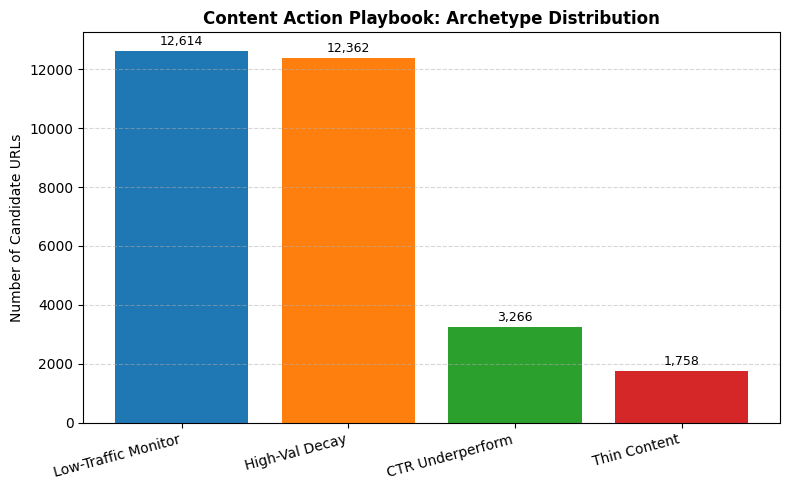

Successfully exported figure to work/figures/action_archetype_distribution.png


In [10]:
# 1. Export Ranked Action Queue CSV
export_cols = [
    'client_id', 'content_age_days', 'impressions_90d', 'clicks_90d',
    'ctr_decimal', 'avg_position_clean', 'refresh_score',
    'archetype', 'reason_code', 'recommended_action', 'priority', 'requires_human_signoff'
]

df_export = df[export_cols].sort_values(by='refresh_score', ascending=False)
df_export.to_csv("work/outputs/ranked_action_queue.csv", index=False)
print(f"Successfully exported {len(df_export)} rows to work/outputs/ranked_action_queue.csv")

# 2. Export Archetype Distribution Figure
plt.figure(figsize=(8, 5))
counts = df['archetype'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = plt.bar(counts.index, counts.values, color=colors[:len(counts)])
plt.title("Content Action Playbook: Archetype Distribution", fontsize=12, fontweight='bold')
plt.ylabel("Number of Candidate URLs")
plt.xticks(
    range(len(counts)),
    ['Low-Traffic Monitor', 'High-Val Decay', 'CTR Underperform', 'Thin Content'],
    rotation=15, ha='right'
)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f"{yval:,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("work/figures/action_archetype_distribution.png", dpi=300)
plt.show()

print("Successfully exported figure to work/figures/action_archetype_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.